In [7]:
import os

import glob
import matplotlib.pyplot as plt
import numpy as np
import torch

In [8]:
def correct_hh_for_tau(hh_list, taus_list):
    """
    Correct hh weights by multiplying each row by the corresponding tau.
    Returns a new list of corrected hh matrices.
    """
    corrected_hh = []
    for hh, taus in zip(hh_list, taus_list):
        hh_corr = hh.copy()
        for i in range(hh.shape[0]):
            hh_corr[i, :] *= taus[i]
        corrected_hh.append(hh_corr)
    return corrected_hh

def frob_normalize(hh_list, ih_list=None, ho_list=None):
    """
    Normalize hh, ih, ho within each fit by the Frobenius norm of hh.
    Returns normalized copies; originals are unchanged.
    """
    hh_norm, ih_norm, ho_norm = [], [], []
    for f, hh in enumerate(hh_list):
        scale = np.linalg.norm(hh, 'fro')
        hh_norm.append(hh / scale)
        if ih_list is not None:
            ih_norm.append(ih_list[f] / scale)
        if ho_list is not None:
            ho_norm.append(ho_list[f] / scale)
    return (np.array(hh_norm),
            np.array(ih_norm) if ih_list is not None else None,
            np.array(ho_norm) if ho_list is not None else None)

In [ ]:
result_taus = []
result_hh = []
result_ih = []
result_ho = []

kernel_tau = 2
tau_effect = 'decay'
result_files = glob.glob(f"rnn_results/kerneltau{kernel_tau}_taueffect{tau_effect}_distgroups*")

for d in result_files:
    if os.path.isfile(d+'/output_0.png'):
        rnn = torch.load(d+'/best_model.pth')
        result_taus.append(rnn['taus'])
        result_hh.append(rnn['hh.weight'])
        result_ih.append(rnn['ih.weight'])
        result_ho.append(rnn['ho.weight'])
    else:
        # print(f'{d} still running')
        continue

result_taus = np.array(result_taus)
result_hh = np.array(result_hh)
result_ih = np.array(result_ih)
result_ho = np.array(result_ho)

# result_hh = correct_hh_for_tau(result_hh, result_taus)
result_hh, result_ih, result_ho = frob_normalize(result_hh, result_ih, result_ho)

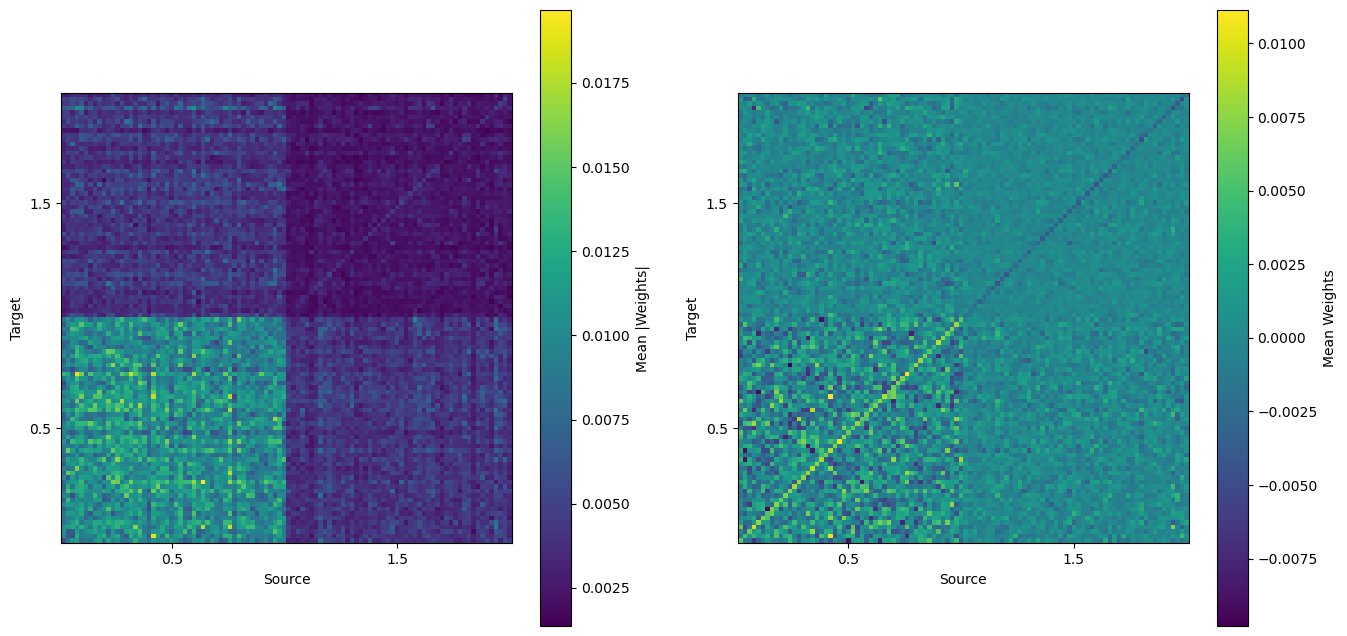

In [10]:
plt.figure(figsize=(16,8))

plt.subplot(1, 2, 1)
img = plt.imshow(np.mean(np.abs(result_hh[:, ::-1]), axis=0))
# img = plt.imshow(np.abs(np.mean(result_hh, axis=0)))
plt.colorbar(img, label='Mean |Weights|')
plt.xticks([24, 74],[0.5, 1.5])
plt.yticks([24, 74],[1.5, .5])
plt.xlabel('Source')
plt.ylabel('Target')

plt.subplot (1, 2, 2)
img = plt.imshow(np.mean(result_hh[:, ::-1], axis=0))
plt.colorbar(img, label='Mean Weights')
plt.xticks([24, 74],[0.5, 1.5])
plt.yticks([24, 74],[1.5, .5])
plt.xlabel('Source')
plt.ylabel('Target');

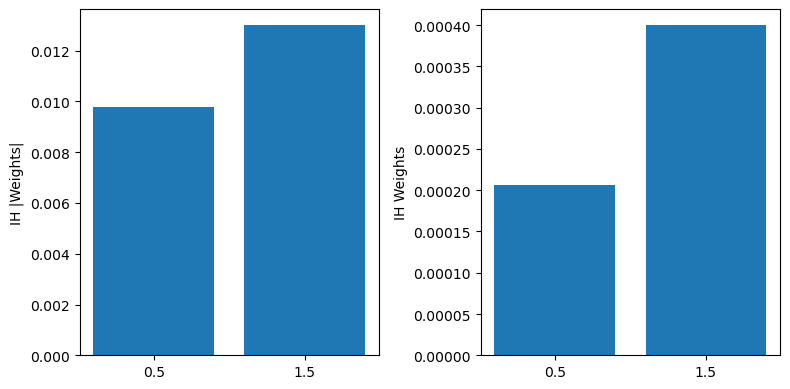

In [11]:
x = [0.5, 1.5]
y = [np.mean(result_ih[:, 0:50]), np.mean(result_ih[:, 50::])]
y_abs = [np.mean(np.abs(result_ih[:, 0:50])), np.mean(np.abs(result_ih[:, 50::]))]

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.bar(x, y_abs)
plt.xticks([0.5, 1.5],[0.5, 1.5])
plt.ylabel('IH |Weights|')

plt.subplot(1, 2, 2)
plt.bar(x, y)
plt.xticks([0.5, 1.5],[0.5, 1.5])
plt.ylabel('IH Weights')

plt.tight_layout()

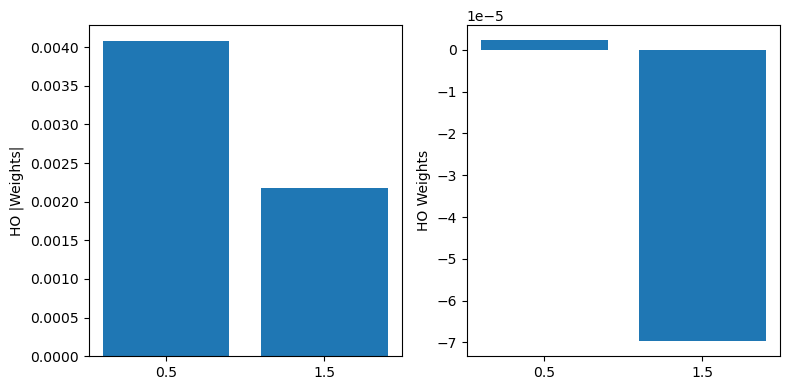

In [12]:
x = [0.5, 1.5]
y = [np.mean(result_ho[:, :, :50]), np.mean(result_ho[:, :, 50::])]
y_abs = [np.mean(np.abs(result_ho[:, :, 0:50])), np.mean(np.abs(result_ho[:, :, 50::]))]

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.bar(x, y_abs)
plt.xticks([0.5, 1.5],[0.5, 1.5])
plt.ylabel('HO |Weights|')

plt.subplot(1, 2, 2)
plt.bar(x, y)
plt.xticks([0.5, 1.5],[0.5, 1.5])
plt.ylabel('HO Weights')

plt.tight_layout()